3. Implement Grover’s search algorithm for a 2-qubit search problem

In [1]:
!pip install qiskit
!pip install qiskit-aer
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 72.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=806963a750174f8122b1a51e5f489ee21e4e7d3783af74186f704cc1fbe83d5d
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


Result: {'01': 1024}


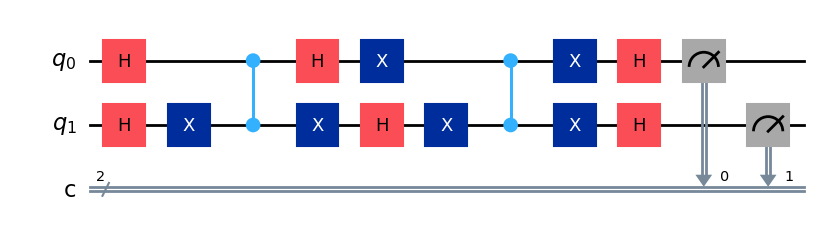

In [2]:
#3. Implement Grover’s search algorithm for a 2-qubit search problem

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

# Create circuit
qc = QuantumCircuit(2, 2)

# Step 1: Superposition
qc.h([0, 1])

# Step 2: Oracle for target = "10"
# Convert |10> → |11> using X on qubit 1
qc.x(1)
qc.cz(0, 1)
qc.x(1)

# Step 3: Diffusion Operator
qc.h([0, 1])
qc.x([0, 1])
qc.cz(0, 1)
qc.x([0, 1])
qc.h([0, 1])

# Step 4: Measurement
qc.measure([0, 1], [0, 1])

# Execute
backend = AerSimulator()
result = backend.run(transpile(qc, backend), shots=1024).result()

print("Result:", result.get_counts())

qc.draw('mpl')